In [ ]:
!pip install mne

In [ ]:
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import mne

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/data.zip'
extract_path = '/content/chb01_data'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

data_dir = os.path.join(extract_path, 'data')
print(sorted(os.listdir(data_dir)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.DS_Store', 'chb01-summary.txt', 'chb01_01.edf', 'chb01_03.edf', 'chb01_03.edf.seizures', 'chb01_04.edf', 'chb01_04.edf.seizures', 'chb01_05.edf', 'chb01_15.edf', 'chb01_15.edf.seizures', 'chb01_16.edf', 'chb01_16.edf.seizures', 'chb01_18.edf', 'chb01_18.edf.seizures', 'chb01_21.edf', 'chb01_21.edf.seizures', 'chb01_26.edf', 'chb01_26.edf.seizures']


In [ ]:
TARGET_CHANNELS = ['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']  # your EDF's naming, confirm this suffix still applies
N_LEVELS = 16          # Section III-B
N_CORE_LEVELS = 12     # min -> level 2, max -> level 13, so 13-2 = 11 steps... check this against your derivation
WINDOW_SAMPLES = 2048  # Section IV-A, 8s @ 256Hz, training window length
SFREQ = 256            # Hz, CHB-MIT acquisition rate

REFERENCE_FILE = 'chb01_03.edf'   # "first 5 minutes from one of the training records" — your old code used this
REFERENCE_TMIN, REFERENCE_TMAX = 0, 300  # 5 minutes, in seconds

TARGET_FILE = 'chb01_16.edf'
SEIZURE_START, SEIZURE_END = 1015, 1066  # from chb01-summary.txt

In [ ]:
def load_raw(filename, channels=TARGET_CHANNELS):
    path = os.path.join(data_dir, filename)
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    return raw.copy().pick(channels)

raw_ref = load_raw(REFERENCE_FILE)
raw_target = load_raw(TARGET_FILE)

print(raw_ref.ch_names)
print(raw_target.ch_names)

/tmp/ipykernel_1352/3819481341.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
/tmp/ipykernel_1352/3819481341.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']
['F7-T7', 'T7-P7', 'F8-T8', 'T8-P8-0']


In [ ]:
ref_data_uv = raw_ref.get_data(tmin=REFERENCE_TMIN, tmax=REFERENCE_TMAX) * 1e6  # (4, n_samples)
print(ref_data_uv.shape)

(4, 76800)


In [ ]:
def compute_reference_stats(ref_data_uv,n_core_levels = 12):
  ch_min = ref_data_uv.min(axis=1)
  ch_max = ref_data_uv.max(axis=1)
  step = (ch_max - ch_min) / n_core_levels
  return ch_min,ch_max,step

def amplitude_to_level(voltage, ch_min, ch_max, step,n_levels = 16):
  start = ch_min - 2 * step
  edges = start + step * np.arange(n_levels + 1)
  bin_edges = edges
  level = np.digitize(voltage, bin_edges) - 1
  level = np.clip(level, 0, n_levels - 1)
  return level


In [ ]:
ch_min, ch_max, step = compute_reference_stats(ref_data_uv)
print(ch_min, ch_max, step)

[-232.67399267 -244.78632479 -198.29059829 -165.86080586] [181.48962149 154.13919414 192.42979243 170.94017094] [34.51363451 33.24379324 32.56003256 28.06674807]


In [ ]:
print(amplitude_to_level(ch_min[0], ch_min[0], ch_max[0], step[0]))  # expect 2
print(amplitude_to_level(ch_max[0], ch_min[0], ch_max[0], step[0]))  # expect 13

2
13


In [ ]:
ref_data_uv.shape

(4, 76800)

In [ ]:
data_uv = raw_target.get_data() * 1e6

In [ ]:
def encode_to_spikes(data_uv, ch_min, ch_max, step, n_levels=16,sfreq = 256):
  n_channels, n_samples = data_uv.shape
  spike_matrix = np.zeros((n_channels * n_levels,n_samples))
  for ch_i in range(n_channels):
    levels = amplitude_to_level(data_uv[ch_i], ch_min[ch_i], ch_max[ch_i], step[ch_i],n_levels = 16)
    levels = np.clip(levels, 0, n_levels - 1)
    for t in range(n_samples):
        row = ch_i * n_levels + levels[t]
        spike_matrix[row, t] = 1

  return spike_matrix


In [ ]:
spike_matrix = encode_to_spikes(data_uv, ch_min, ch_max, step)
print(spike_matrix.shape)          # expect (64, n_samples)
print(spike_matrix.sum(axis=0)[:10])  # expect exactly 4 per column (one spike per channel per timestep)

(64, 921600)
[4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]


In [ ]:
def make_windows(spike_matrix, sfreq, seizure_start, seizure_end,
                  window_size=2048, label_threshold=0.5):
    n_rows, n_samples = spike_matrix.shape

    seizure_start_sample = seizure_start * sfreq
    seizure_end_sample = seizure_end * sfreq

    windows = []
    labels = []

    for start in range(0, n_samples - window_size + 1, window_size):  # non-overlapping: stride == window_size
        end = start + window_size
        window = spike_matrix[:, start:end]

        overlap = max(0, min(end, seizure_end_sample) - max(start, seizure_start_sample)) # ... how much of [start, end) intersects [seizure_start_sample, seizure_end_sample)?
        fraction = overlap / window_size
        label = 1 if fraction >= label_threshold else 0

        windows.append(window)
        labels.append(label)

    return np.array(windows), np.array(labels)

In [ ]:
windows, labels = make_windows(spike_matrix, sfreq=256, seizure_start=1015, seizure_end=1066)
print(windows.shape)   # expect (n_windows, 64, 2048)
print(labels.shape)    # expect (n_windows,)
print(labels.sum())    # how many windows got labeled seizure?

(450, 64, 2048)
(450,)
6


In [ ]:
sfreq = raw_target.info["sfreq"]

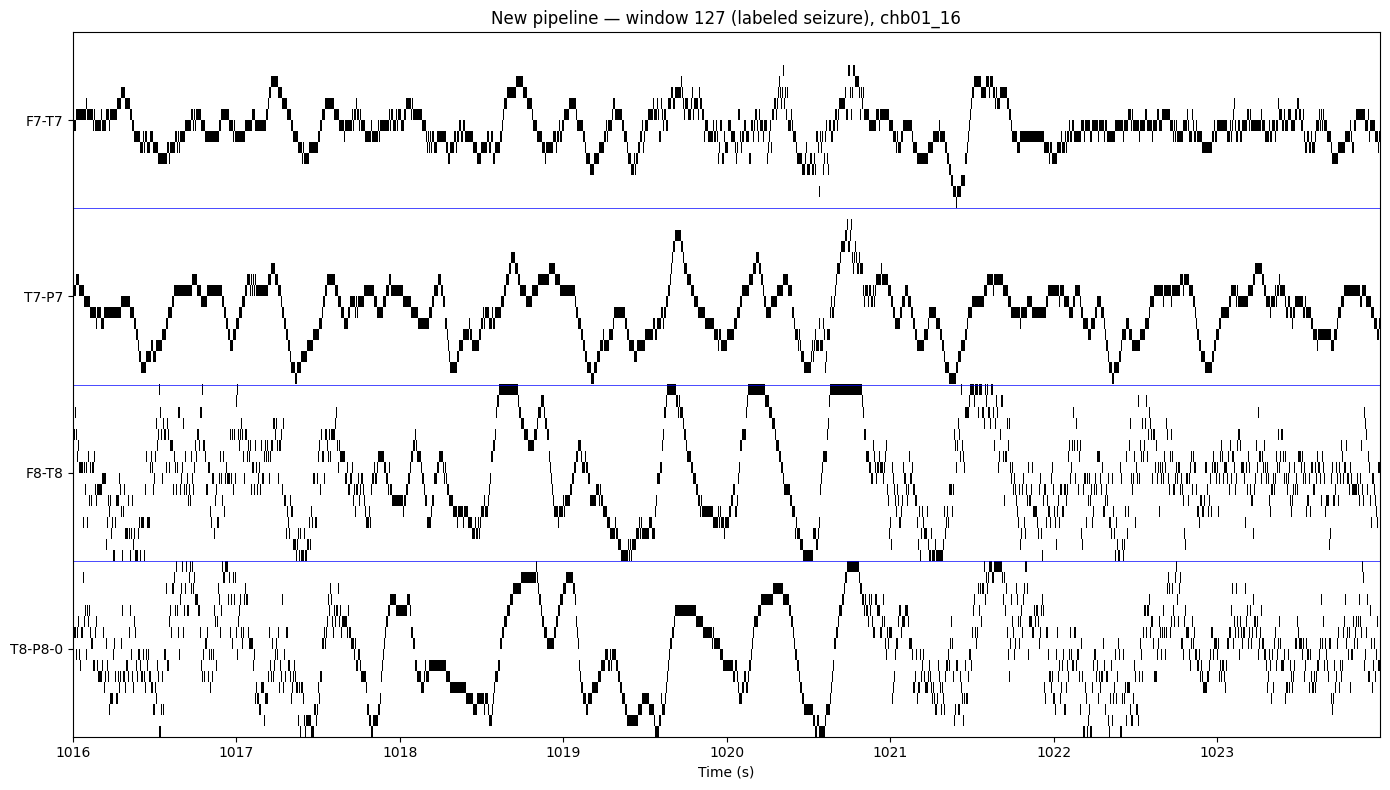

Window 127 spans 1016.0s to 1024.0s
Seizure interval: 1015s to 1066s


In [ ]:
seizure_window_idx = np.where(labels == 1)[0][0]  # first seizure-labeled window
window = windows[seizure_window_idx]               # shape (64, 2048)

window_start_sample = seizure_window_idx * 2048
window_times = np.arange(2048) / sfreq + window_start_sample / sfreq

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(window, aspect='auto', cmap='Greys', interpolation='none',
          extent=[window_times[0], window_times[-1], 64, 0])
for ch_i in range(4):
    ax.axhline(ch_i * 16, color='blue', linewidth=0.5)
ax.set_yticks([ch_i * 16 + 8 for ch_i in range(4)])
ax.set_yticklabels(TARGET_CHANNELS)
ax.set_xlabel('Time (s)')
ax.set_title(f'New pipeline — window {seizure_window_idx} (labeled seizure), chb01_16')
plt.tight_layout()
plt.show()

print(f"Window {seizure_window_idx} spans {window_times[0]:.1f}s to {window_times[-1]:.1f}s")
print(f"Seizure interval: {SEIZURE_START}s to {SEIZURE_END}s")

In [ ]:
normal_window_idx = np.where(labels == 0)[0][0]

In [ ]:
old_spike_matrix = np.load('/content/drive/MyDrive/old_spike_matrix.npy')
print("Old slice shape:", old_spike_matrix.shape)  # expect (64, 2560)

Old slice shape: (128, 2560)


In [ ]:
sfreq = int(sfreq)

old = np.load('/content/drive/MyDrive/old_spike_matrix.npy')
new = spike_matrix[:, 1010*sfreq : 1020*sfreq]

print("old shape:", old.shape)
print("new shape:", new.shape)
print("match:", np.array_equal(old, new))

old shape: (64, 2560)
new shape: (64, 2560)
match: True
